# **Refatoração dos dados**

In [148]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# 1) Ler CSV
dataset = pd.read_csv('googleplaystore.csv')

# 2) Reviews -> numérico
dataset['Reviews'] = pd.to_numeric(dataset['Reviews'], errors='coerce')

# 3) App em minúsculas (normaliza) e remove espaços extras
dataset['App'] = dataset['App'].astype(str).str.lower().str.strip()

# 4) Remover duplicatas mantendo o maior Reviews por app
dataset = (dataset.sort_values('Reviews', ascending=False)
                  .drop_duplicates(subset=['App'], keep='first'))

# 5) Installs -> inteiro ANULÁVEL (aceita NA)
#    - remove tudo que não for dígito; '' vira NA; converte para Int64 (pandas nullable int)
dataset['Installs'] = (dataset['Installs'].astype(str)
                       .str.replace(r'[^0-9]', '', regex=True)
                       .replace('', pd.NA)
                       .astype('Int64'))


# 6) Price -> float (robusto)
#    - remove '$', vírgulas etc; '' vira NA; converte para float anulável
dataset['Price'] = (dataset['Price'].astype(str)
                    .str.replace(r'[^0-9.\-]', '', regex=True)
                    .replace('', pd.NA)
                    .astype('Float64'))

# (Opcional) se existir a coluna Type, define 0 para apps Free com Price ausente
if 'Type' in dataset.columns:
    dataset.loc[(dataset['Type'].astype(str).str.lower() == 'free') &
                (dataset['Price'].isna()), 'Price'] = 0.0

# 7) Category: troca '_' por espaço e tira espaços extras
dataset['Category'] = (dataset['Category'].astype(str)
                       .str.replace('_', ' ', regex=False)
                       .str.strip())

display(dataset.head())



,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
2544,facebook,SOCIAL,4.1,78158306.0,Varies with device,1000000000,Free,0.0,Teen,Social,"August 3, 2018",Varies with device,Varies with device
381,whatsapp messenger,COMMUNICATION,4.4,69119316.0,Varies with device,1000000000,Free,0.0,Everyone,Communication,"August 3, 2018",Varies with device,Varies with device
2604,instagram,SOCIAL,4.5,66577446.0,Varies with device,1000000000,Free,0.0,Teen,Social,"July 31, 2018",Varies with device,Varies with device
382,messenger – text and video chat for free,COMMUNICATION,4.0,56646578.0,Varies with device,1000000000,Free,0.0,Everyone,Communication,"August 1, 2018",Varies with device,Varies with device
1879,clash of clans,GAME,4.6,44893888.0,98M,100000000,Free,0.0,Everyone 10+,Strategy,"July 15, 2018",10.322.16,4.1 and up


# **Top 5 Aplicativos Mais Instalados na Google Play Store**
#### Critério de desempate foi o número de reviews

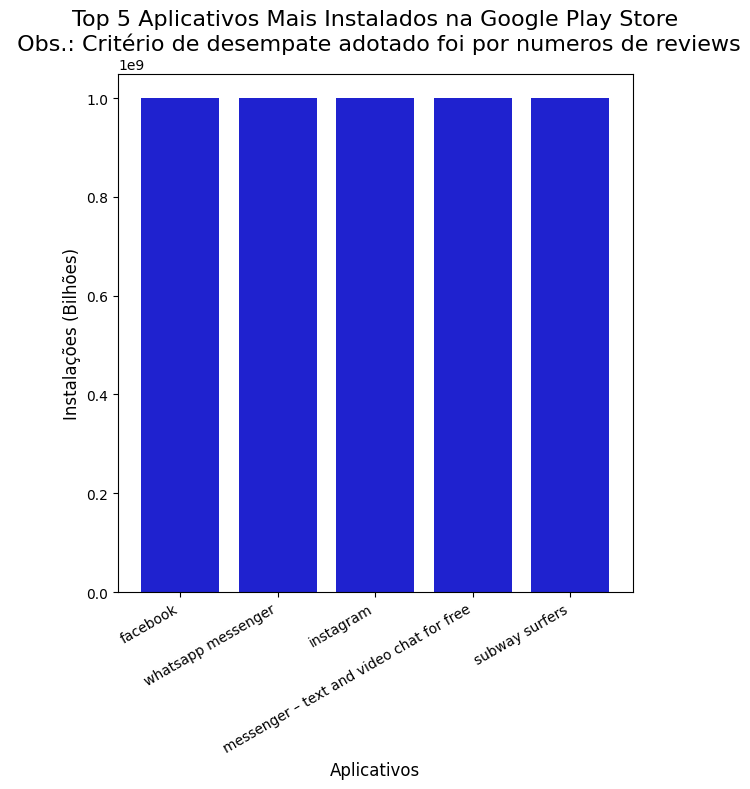

In [149]:
top_installs = dataset.sort_values(['Installs','Reviews'], ascending=False, inplace=False).head(5)

fig, ax = plt.subplots(figsize=(6, 8))

ax.set_facecolor("#FFFFFF")  

#Configurações de gráfico de barra
plt.bar(top_installs['App'], top_installs['Installs'], color="#1F22CF")
plt.xlabel('Aplicativos', fontsize=12)
plt.ylabel('Instalações (Bilhões)', fontsize=12)
plt.title('Top 5 Aplicativos Mais Instalados na Google Play Store\n Obs.: Critério de desempate adotado foi por numeros de reviews', fontsize=16)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()

# Exibição do gráfico
plt.show()

# **Frequência de aplicativos por categoria**

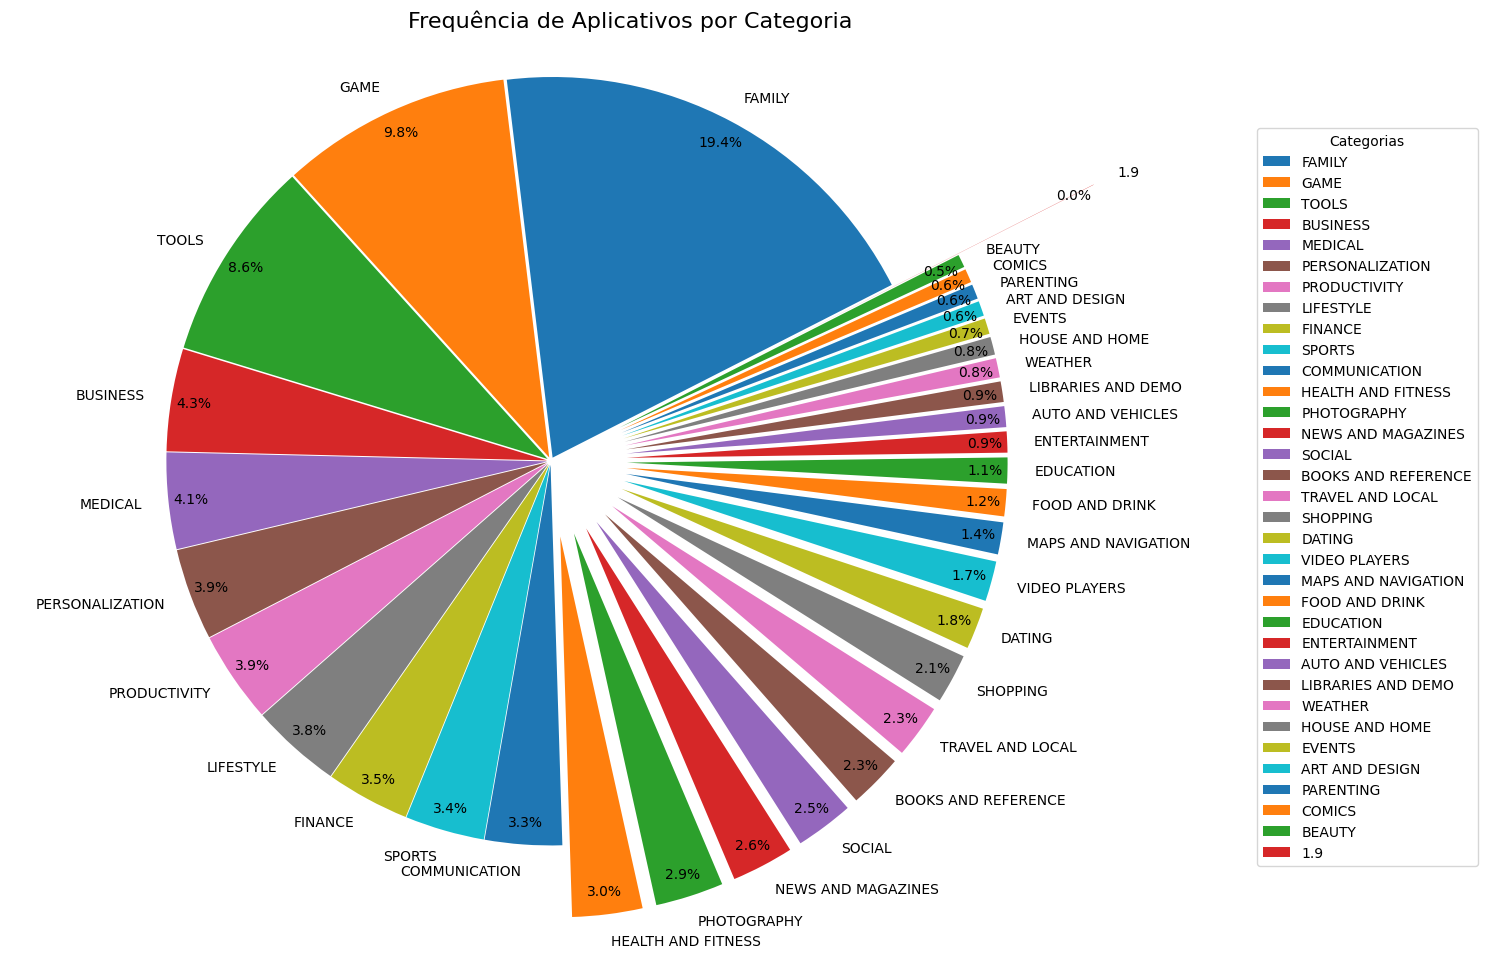

In [150]:
# Contando a frequencia de cada categoria
frequency_apps_by_category = dataset['Category'].value_counts()

#Adicionando explode diferentes para quantidades variadas para fins de legibilidade
explode = []
for count in frequency_apps_by_category:
    if count > 300:
        explode.append(0.01)
    elif count >50:
        explode.append(0.2)  
    else:
        explode.append(0.6)

#Configurando o gráfico de pizza
plt.figure(figsize=(16, 12))
plt.pie(
    frequency_apps_by_category,
    explode=explode,
    labels=frequency_apps_by_category.index,
    labeldistance= 1.07,
    autopct='%1.1f%%',
    pctdistance=0.94,
    startangle=27,
)
plt.title('Frequência de Aplicativos por Categoria',fontsize=16)
plt.axis('equal')

#Adicionando legenda e ajustando sua posição com loc e bbox_to_anchor
plt.legend( frequency_apps_by_category.index, title="Categorias", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.show()

# **Aplicativo mais caro**

In [151]:
# Selecionando o aplicativo mais caro
app_mais_caro = dataset.loc[dataset['Price'].idxmax()]

# Adicionando informações do app com maior preço
texto = (
    f"App mais caro\n\n"
    f"App: {app_mais_caro['App']}\n"
    f"Categoria: {app_mais_caro['Category']}\n"
    f"Preço: ${app_mais_caro['Price']:.2f}"
)

display(app_mais_caro)

App               i'm rich - trump edition
Category                         LIFESTYLE
Rating                                 3.6
Reviews                              275.0
Size                                  7.3M
Installs                             10000
Type                                  Paid
Price                                400.0
Content Rating                    Everyone
Genres                           Lifestyle
Last Updated                   May 3, 2018
Current Ver                          1.0.1
Android Ver                     4.1 and up
Name: 4367, dtype: object

# **Contagem de apps com classificação Mature 17+**

In [152]:
total_mature = (dataset['Content Rating'] == 'Mature 17+').sum()
print('Total de apps Mature 17+:', int(total_mature))


Total de apps Mature 17+: 393


# **Top 10 apps mais visualizados**

,App,Reviews
2544,facebook,78158306.0
381,whatsapp messenger,69119316.0
2604,instagram,66577446.0
382,messenger – text and video chat for free,56646578.0
1879,clash of clans,44893888.0
4005,clean master- space cleaner & antivirus,42916526.0
1917,subway surfers,27725352.0
3665,youtube,25655305.0
7536,"security master - antivirus, vpn, applock, boo...",24900999.0
1878,clash royale,23136735.0


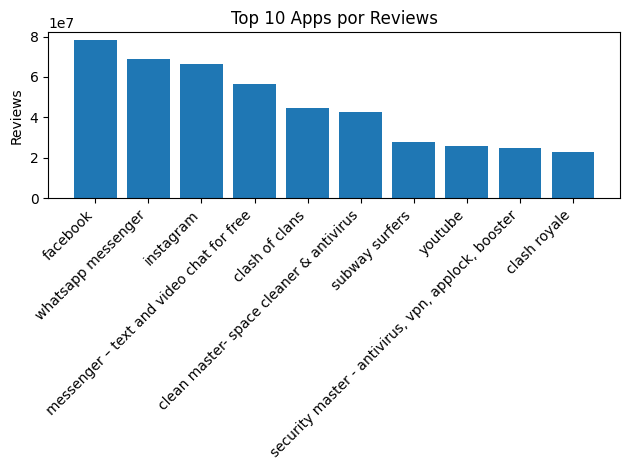

In [153]:
top_reviews = (
    dataset[['App', 'Reviews']]
    .dropna(subset=['App', 'Reviews'])
    .sort_values('Reviews', ascending=False)
    .drop_duplicates(subset=['App'])
    .head(10)
)

# Exibe a lista e o gráfico de barras
display(top_reviews)

plt.figure()
plt.bar(top_reviews['App'], top_reviews['Reviews'])
plt.title('Top 10 Apps por Reviews')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Reviews')
plt.tight_layout()
plt.show()


# **Top 5 Apps gratuitos com mais visualizações**

In [154]:
# Criando um dataFrame para armazenar apenas os aplicativos pagos
paid_apps = dataset.loc[dataset['Type'] == 'Free']

# Selecionando os 5 apps com mais visualizações
top_5_apps_paid = paid_apps.sort_values(['Reviews'], ascending=False, inplace=False).head(5)

# Selecionado apenas as colunas Apps, Reviews e Category
top_5_apps_paid = top_5_apps_paid[['App', 'Reviews', 'Category']].reset_index(drop=True)

# Criando a coluna de ranking com 1°, 2°, 3°...
ranking = [f"{i}°" for i in range(1, 6)]

# Adicionando a coluna de ranking ao DataFrame
top_5_apps_paid.insert(0, 'Ranking', ranking)



# Exibi o dataFrame
display(top_5_apps_paid)


,Ranking,App,Reviews,Category
0,1°,facebook,78158306.0,SOCIAL
1,2°,whatsapp messenger,69119316.0,COMMUNICATION
2,3°,instagram,66577446.0,SOCIAL
3,4°,messenger – text and video chat for free,56646578.0,COMMUNICATION
4,5°,clash of clans,44893888.0,GAME


# **App pago com melhor avaliação e o mais instalado**

In [155]:
# Ordenando aplicativos pagos pelos valores das colunas 'Rating' e 'Installs' em ordem decrescente
best_rated_and_viewed_apps = paid_apps.sort_values(['Rating', 'Installs'], ascending=False, inplace=False)

# Selecionar apenas as colunas 'App', 'Installs' e 'Rating', retirando o índice e pegando apenas o primeiro
best_rated_and_viewed_apps = best_rated_and_viewed_apps[['App', 'Installs', 'Rating']].reset_index(drop=True).head(1)

# Adicionando informações do app com maior preço
texto = (
    f"App pago melhor avaliado e o mais instalado\n\n"
    f"App: {best_rated_and_viewed_apps.loc[0, 'App']}\n"
    f"Avaliação: {best_rated_and_viewed_apps.loc[0, 'Rating']}\n"
    f"Downloads: {best_rated_and_viewed_apps.loc[0, 'Installs']:,}"
)
print(best_rated_and_viewed_apps)


                        App  Installs  Rating
0  ek bander ne kholi dukan     10000     5.0


# **Histograma de preços (Apenas apps pagos)**

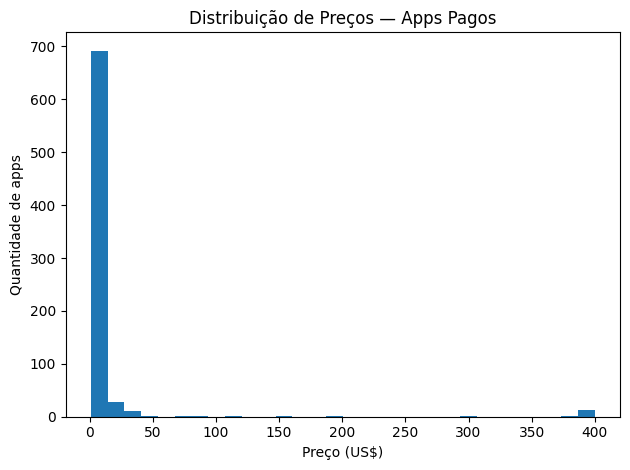

In [ ]:
dataset['Type']  = dataset['Type'].astype(str).str.lower().str.strip()
dataset['Price'] = pd.to_numeric(dataset['Price'], errors='coerce')

# filtra apenas apps pagos (Type = 'paid'), que tenham preço não-nulo e maior que zero
paid = dataset[(dataset['Type'] == 'paid') & (dataset['Price'].notna()) & (dataset['Price'] > 0)]

plt.figure()
plt.hist(paid['Price'], bins=30)
plt.title('Distribuição de Preços — Apps Pagos')
plt.xlabel('Preço (US$)')
plt.ylabel('Quantidade de apps')
plt.tight_layout()
plt.show()



# **Distribuição de Apps: Gratuitos vs Pago**

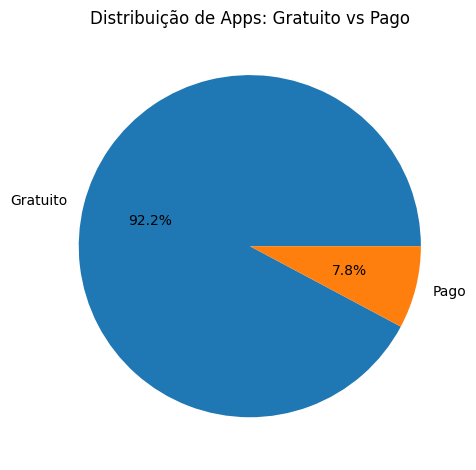

In [ ]:
tipo_series = (dataset['Type'].astype(str)
               .str.lower()
               .map({'free': 'Gratuito', 'paid': 'Pago'}))  
dist_tipo = tipo_series.value_counts(dropna=True)
# pega a coluna "Type", garante que é string e em minúsculo
# depois substitui os valores: "free" → "Gratuito" e "paid" → "Pago"


plt.figure()
# conta quantos apps gratuitos e pagos existem no dataset
dist_tipo.plot(kind='pie', autopct='%1.1f%%')

plt.title('Distribuição de Apps: Gratuito vs Pago')
plt.ylabel('')
plt.tight_layout()
plt.show()

# **Referências**:
- https://matplotlib.org/stable/
- https://pt.stackoverflow.com/